In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Load and Split Data

In [3]:
data = pd.read_csv('yelp_labelled_edited.txt', sep="\t")
data.head()

,Text,Review
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [4]:
X_train = data['Text']

### Text Preprocessing

In [5]:
import nltk
custom_dir = '.devenv/state/venv/nltk_data' 
nltk.download('punkt_tab', download_dir=custom_dir)
nltk.download('stopwords', download_dir=custom_dir)
nltk.download('wordnet', download_dir=custom_dir)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     .devenv/state/venv/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     .devenv/state/venv/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     .devenv/state/venv/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
def preprocess_text(text):
    import re, string
    from nltk.tokenize import word_tokenize 
    from nltk.corpus import stopwords 
    from nltk.stem import WordNetLemmatizer    
    
    word_tokens = word_tokenize(text)
    word_tokens = [word.lower() for word in word_tokens] 
    word_tokens = [re.sub(r'[^\w\s]', '', token) for token in word_tokens if re.sub(r'[^\w\s]', '', token)]
    corpus_stop_words = set(stopwords.words('english')) 
    word_tokens = [word for word in word_tokens if not word in corpus_stop_words] 
    lemmatizer = WordNetLemmatizer()
    word_tokens = [lemmatizer.lemmatize(word) for word in word_tokens]
    return word_tokens

In [7]:
processed_X_train = [preprocess_text(word) for word in X_train]
processed_X_train

[['wow', 'loved', 'place'],
 ['crust', 'good'],
 ['tasty', 'texture', 'nasty'],
 ['stopped',
  'late',
  'may',
  'bank',
  'holiday',
  'rick',
  'steve',
  'recommendation',
  'loved'],
 ['selection', 'menu', 'great', 'price'],
 ['getting', 'angry', 'want', 'damn', 'pho'],
 ['honeslty', 'nt', 'taste', 'fresh'],
 ['potato',
  'like',
  'rubber',
  'could',
  'tell',
  'made',
  'ahead',
  'time',
  'kept',
  'warmer'],
 ['fry', 'great'],
 ['great', 'touch'],
 ['service', 'prompt'],
 ['would', 'go', 'back'],
 ['cashier', 'care', 'ever', 'say', 'still', 'ended', 'wayyy', 'overpriced'],
 ['tried', 'cape', 'cod', 'ravoli', 'chicken', 'cranberry', 'mmmm'],
 ['disgusted', 'pretty', 'sure', 'human', 'hair'],
 ['shocked', 'sign', 'indicate', 'cash'],
 ['highly', 'recommended'],
 ['waitress', 'little', 'slow', 'service'],
 ['place', 'worth', 'time', 'let', 'alone', 'vega'],
 ['like'],
 ['burrittos', 'blah'],
 ['food', 'amazing'],
 ['service', 'also', 'cute'],
 ['could', 'care', 'less', 'interi

### Text Representation

In [8]:
# Convert nested list to word2vec vectors

In [9]:
selected_vector_size = 25

from gensim.models import Word2Vec
w2v_model = Word2Vec(sentences=processed_X_train,
                 vector_size=selected_vector_size,   # size of word embeddings
                 window=5,          # context window size
                 min_count=1,       # include all words
                 workers=4,         # number of CPU threads used to train the model in parallel.
                 sg=0               # CBOW
                )

In [10]:
def average_vectors(token_vector, vector_size=100):
    # token_vector = list of tokens or vocabs from one review
    # This function will:
    # 1) retrieve word vectors of all vocabs from models
    # 2) average word vectors to get one representative vector for each review

    # Get word vectors from CBOW model
    word_vectors = [w2v_model.wv[word] for word in token_vector if word in w2v_model.wv]
    # If no word exists in the model, return array of 100 zeros
    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    # Convert word vectors to numpy arrays
    word_vectors_np = np.array(word_vectors)
    # Average numerical word vectors and return
    return word_vectors_np.mean(axis=0)

X_train_vectors = np.array([average_vectors(token_vector, selected_vector_size) for token_vector in processed_X_train])

### Training Model and Evaluate Performance

In [11]:
from sklearn.preprocessing import normalize
X_train_norm = normalize(X_train_vectors)

In [12]:
# Clustering Model

In [13]:
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)

    # Compute cluster centroids
    centroids = np.array([
        X[labels == k].mean(axis=0) for k in unique_clusters
    ])
    
    from scipy.spatial.distance import cdist
    # Inter-cluster distance (minimum distance between clusters)
    inter_cluster_dist = np.min(
        cdist(centroids, centroids)[np.triu_indices(len(unique_clusters), k=1)]
    )

    # Intra-cluster distance (maximum cluster diameter)
    intra_cluster_dist = max(
        np.max(cdist(X[labels == k], X[labels == k]))
        for k in unique_clusters
    )
    return inter_cluster_dist / intra_cluster_dist

def evaluate_clustering(X, X_clusters):
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
    silhouette = silhouette_score(X, X_clusters, metric="cosine")
    db = davies_bouldin_score(X, X_clusters)
    dunn = dunn_index(X, X_clusters)
    ch = calinski_harabasz_score(X, X_clusters)
    return silhouette, db, dunn, ch

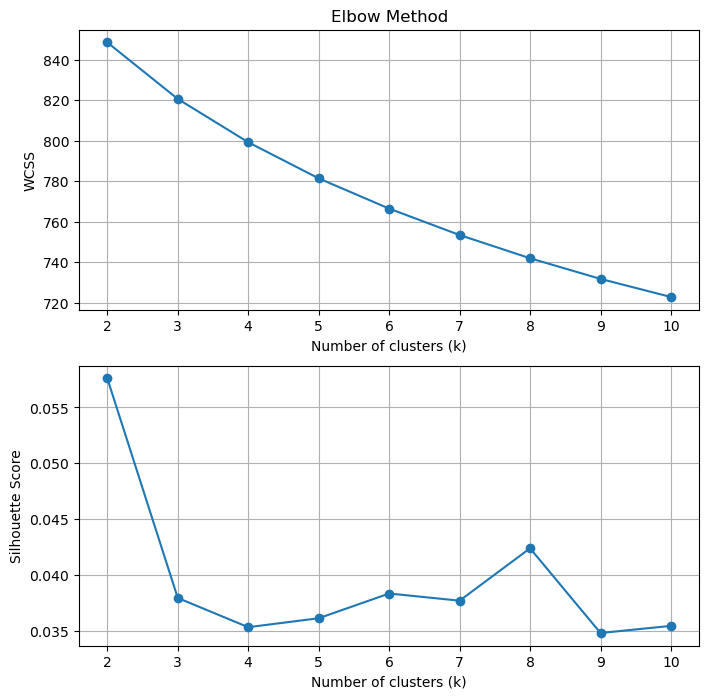

In [14]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

wcss = []
silhouette_scores = []
X_scaled = X_train_norm

k_range = range(2, 11)  # silhouette is undefined for k=1

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=23)
    temp_X_clusters = kmeans.fit_predict(X_scaled)

    # Elbow (WCSS)
    wcss.append(kmeans.inertia_)

    # Silhouette
    silhouette = silhouette_score(X_scaled, temp_X_clusters)
    silhouette_scores.append(silhouette)

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")
axes[0].grid(True)

axes[1].plot(k_range, silhouette_scores, marker='o')
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)
#axes[1].set_title("Silhouette Score vs Number of Clusters")
plt.show()

In [15]:
selected_k = 2  # number of resulting clusters
selected_n_init = 15    # number of times the k-means algorithm is run with different centroid seeds
model = KMeans(n_clusters=selected_k, n_init=selected_n_init, random_state=23)   
    
X_clusters_Kmean = model.fit_predict(X_train_norm)

# Performance Evaluation
def cluster_eva(X_scaled, X_clusters_Kmean):
    silhouette, db, dunn, ch = evaluate_clustering(X_scaled, X_clusters_Kmean)
    print('Selected k: ', selected_k)
    print('Silhouette Index: ', silhouette)
    print('Davies-Bouldin Index: ', db)
    print('Dunn Index: ', dunn)
    print('CH Index: ', ch)

cluster_eva(X_train_norm, X_clusters_Kmean)

Selected k:  2
Silhouette Index:  0.1046806052327156
Davies-Bouldin Index:  4.132706253663268
Dunn Index:  0.23259196172835306
CH Index:  58.046600341796875


In [16]:
labels = model.labels_
print("Cluster labels:", labels)

Cluster labels: [1 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 0 1 0 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1
 1 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 1 1 0 1 0 0 0 1
 1 0 1 1 0 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1
 0 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1
 0 1 0 1 1 1 0 0 1 1 0 0 1 0 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 0 1
 0 0 0 0 1 1 0 1 1 0 0 0 0 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 1 1 0 1
 1 1 0 1 1 0 0 1 1 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 0
 0 1 1 1 1 0 1 1 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1
 0 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0
 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 1 1 1 0 0 1 0 0 0 1 1 0 1 1 1 0 1 1 1 0 0 0
 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 0 1
 0 0 0 1 1 0 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 0 1
 1 0 1 0 

In [17]:
from sklearn.cluster import AgglomerativeClustering

selected_linkage = 'ward'  # 'others are 'complete', 'single', 'average', 'ward'
# To partition dendrogram to clusters, either choose to do 1) or 2) [but not both]
# 1) Set distance_threshold to be cut-off distance (looking for cut-off distance on y-axis of dendrogram)
#    If distance_threshold is not None, set n_clusters to be None.
selected_distance_threshold = None
selected_n_clusters = 2
# 2) Set n_clusters to be your selected number of clusters
#    If n_clusters is not None, set distance_threshold to be None.
#selected_distance_threshold = None
#selected_n_clusters = 5

model_cluster=AgglomerativeClustering(linkage=selected_linkage,
                              n_clusters=selected_n_clusters,
                              distance_threshold=selected_distance_threshold)

X_clusters = model_cluster.fit_predict(X_scaled)

# Performance Evaluation
silhouette, db, dunn, ch = evaluate_clustering(X_scaled, X_clusters)
print('Silhouette Index: ', silhouette)
print('Davies-Bouldin Index: ', db)
print('Dunn Index: ', dunn)
print('CH Index: ', ch)
X_clusters

Silhouette Index:  0.04573825001716614
Davies-Bouldin Index:  5.020458177190695
Dunn Index:  0.19031170922097737
CH Index:  36.24986267089844


array([1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,

In [18]:
# 4️⃣ Evaluate (Silhouette score with cosine)
from sklearn.metrics import silhouette_score
score = silhouette_score(X_train_vectors, labels, metric="cosine")
print("Silhouette Score (cosine):", score)

Silhouette Score (cosine): 0.1046806052327156


In [19]:
# For tdidf

def tfidf():
    terms = tfidf_model.get_feature_names_out()  # tfidf model
    centroids = model.cluster_centers_           # clustering model
    
    for i in range(k):
        print(f"\nCluster {i} top words:")
        top_indices = centroids[i].argsort()[-10:][::-1]
        top_terms = [terms[ind] for ind in top_indices]
        print(top_terms)

In [20]:
# For word2vec

def w2v():
    terms = list(w2v_model.wv.key_to_index.keys())   # word2vec model
    centroids = model.cluster_centers_               # clustering model
    
    for i in range(selected_k):
        print(f"\nCluster {i} top words:")
        top_indices = centroids[i].argsort()[-10:][::-1]
        top_terms = [terms[ind] for ind in top_indices]
        print(top_terms)

w2v()


Cluster 0 top words:
['one', 'nice', 'best', 'food', 'time', 'experience', 'friendly', 'service', 'restaurant', 'back']

Cluster 1 top words:
['love', 'time', 'vega', 'one', 'amazing', 'friendly', 'back', 'restaurant', 'also', 'really']


In [21]:
# From the KMeans clustering performance
# Selected k:  2
# Silhouette Index:  0.1046806052327156
# Davies-Bouldin Index:  4.132706253663268
# Dunn Index:  0.23259196172835306
# CH Index:  58.046600341796875
# 
# Tells that the cluster doesn't give a good performance
# As Silhouette score (cosine) < 0.25 = Weak clustering